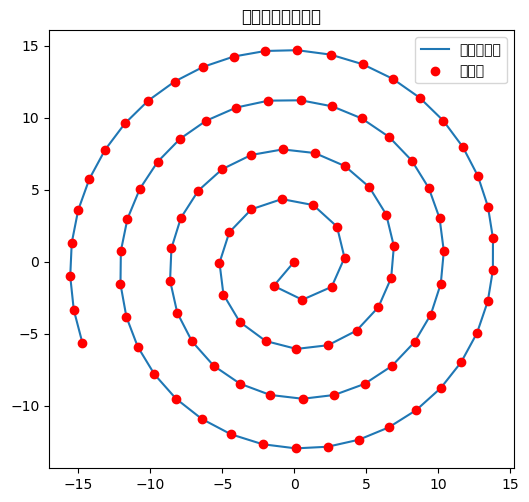

In [3]:
import numpy as np
import matplotlib.pyplot as plt

# 定义固定的距离
fixed_distance = 2.2  # 每个点之间的固定直线距离
a = 0.55  # 螺旋参数，控制螺旋的稀疏程度
num_points = 100  # 生成的点的数量

# 初始值
theta = 0
r = 0
points = [(r * np.cos(theta), r * np.sin(theta))]

# 生成点的循环
for _ in range(1, num_points):
    # 计算相邻点的theta增量，使得直线距离为fixed_distance
    while True:
        theta += 0.01  # 每次增加一个小量
        r = a * theta  # 更新极径
        x, y = r * np.cos(theta), r * np.sin(theta)  # 转换为直角坐标
        # 计算当前点与上一个点的距离
        last_x, last_y = points[-1]
        dist = np.sqrt((x - last_x) ** 2 + (y - last_y) ** 2)
        if dist >= fixed_distance:  # 当距离大于等于固定距离时，保留此点
            points.append((x, y))
            break

# 转换为数组形式以便绘图
points = np.array(points)

# 绘制螺旋线和点
plt.figure(figsize=(6, 6))
plt.plot(points[:, 0], points[:, 1], label='等距螺旋线')
plt.scatter(points[:, 0], points[:, 1], color='red', zorder=5, label='等距点')

plt.gca().set_aspect('equal', adjustable='box')
plt.title('稀疏的等距螺旋线')
plt.legend()
plt.show()


In [7]:
import numpy as np
from scipy.integrate import quad
from scipy.optimize import fsolve
import math

# 定义被积函数
def f(t):
    return math.sqrt((8.8+0.55/2/math.pi*t)**2+(0.55/2/math.pi)**2)  # 假设被积函数为 t^2 + 1

# 目标值
C = 2  # 积分结果应等于C

# 积分上限
a = 0

# 定义目标方程
def F(b):
    integral_result, _ = quad(f, b, a)  # 计算从a到b的定积分
    return integral_result - C  # 希望积分结果等于C

# 使用fsolve求解b
b_solution = fsolve(F, 1.0)  # 使用初始猜测值1.0来搜索解

# 输出结果
print(f"找到的上限 b = {b_solution[0]:10f}")


找到的上限 b =  -0.227519
